# Global Terrorism Database — Complete Data Science Project
### EDA · Machine Learning · Predictive Modeling

| Field | Details |
|---|---|
| **Author** | Saiprakash Yamsani |
| **Dataset** | Global Terrorism Database (GTD) — 181,691 records |
| **Tools** | Python, Pandas, NumPy, Scikit-learn, XGBoost, Matplotlib, Seaborn |
| **Project Type** | EDA + Predictive Modeling |

---
## Project Workflow
1. **Import Libraries**
2. **Load & Inspect Dataset**
3. **Missing Value Analysis**
4. **Data Wrangling & Feature Engineering**
5. **Exploratory Data Analysis (5 Charts + Correlation Heatmap)**
6. **Business Insights & Conclusions**
7. **ML — Fatality Prediction (Regression Pipeline)**
8. **Model Training — Linear Regression, Random Forest, XGBoost**
9. **Hyperparameter Tuning — GridSearchCV**
10. **Feature Importance & Sample Prediction**

---
# Part 1 — Exploratory Data Analysis

## Step 1 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Step 2 — Load Dataset

In [ ]:
df = pd.read_csv('/content/Global Terrorism Data.csv',encoding='latin1')
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0.0,1.0,1.0,1.0,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN


In [ ]:
df.shape

(60236, 135)

In [ ]:
df.describe()

,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,6.023600e+04,60236.000000,60236.000000,60236.000000,60236.000000,60236.000000,60236.000000,56996.000000,5.699500e+04,60236.000000,...,5.960000e+02,1.0,1.360000e+02,3.000000,1435.000000,1100.000000,60235.000000,60235.000000,60235.000000,60235.000000
mean,1.985783e+11,1985.717594,6.390813,15.385899,0.017614,150.586012,5.605850,17.714654,-1.528453e+03,1.423053,...,3.464098e+06,20000.0,1.314346e+06,8775.000000,3.089199,8.460000,-3.423641,-3.382668,0.140533,-2.660430
std,5.919095e+08,5.919556,3.383118,8.799791,0.131545,136.362714,3.217337,24.854135,3.610088e+05,1.103150,...,4.158655e+07,NaN,4.750699e+06,15198.745836,1.427607,33.845918,4.437503,4.488735,0.761247,4.410067
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,0.000000e+00,20000.0,0.000000e+00,0.000000,2.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.981122e+11,1981.000000,3.000000,8.000000,0.000000,61.000000,3.000000,4.667128,-7.632752e+01,1.000000,...,0.000000e+00,20000.0,0.000000e+00,0.000000,2.000000,1.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,1.987021e+11,1987.000000,6.000000,15.000000,0.000000,121.000000,6.000000,14.622869,-5.956210e+00,1.000000,...,5.000000e-01,20000.0,2.700000e+04,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.991012e+11,1991.000000,9.000000,23.000000,0.000000,183.000000,8.000000,38.395649,3.276754e+01,1.000000,...,5.000000e+05,20000.0,5.000000e+05,13162.500000,4.000000,3.000000,0.000000,0.000000,0.000000,1.000000
max,1.995083e+11,1995.000000,12.000000,31.000000,1.000000,605.000000,12.000000,64.837778,1.784419e+02,5.000000,...,1.000000e+09,20000.0,4.100000e+07,26325.000000,7.000000,390.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
eventid,60236.0,1.985783e+11,5.919095e+08,1.970000e+11,1.981122e+11,1.987021e+11,1.991012e+11,1.995083e+11
iyear,60236.0,1.985718e+03,5.919556e+00,1.970000e+03,1.981000e+03,1.987000e+03,1.991000e+03,1.995000e+03
imonth,60236.0,6.390813e+00,3.383118e+00,0.000000e+00,3.000000e+00,6.000000e+00,9.000000e+00,1.200000e+01
iday,60236.0,1.538590e+01,8.799791e+00,0.000000e+00,8.000000e+00,1.500000e+01,2.300000e+01,3.100000e+01
extended,60236.0,1.761405e-02,1.315450e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
...,...,...,...,...,...,...,...,...
nreleased,1100.0,8.460000e+00,3.384592e+01,-9.900000e+01,1.000000e+00,1.000000e+00,3.000000e+00,3.900000e+02
INT_LOG,60235.0,-3.423641e+00,4.437503e+00,-9.000000e+00,-9.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
INT_IDEO,60235.0,-3.382668e+00,4.488735e+00,-9.000000e+00,-9.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
INT_MISC,60235.0,1.405329e-01,7.612466e-01,-9.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


Select Important Columns

In [ ]:
df = df[[
    'iyear',
    'imonth',
    'country_txt',
    'region_txt',
    'city',
    'attacktype1_txt',
    'target1',
    'gname',
    'weaptype1_txt',
    'nkill',
    'nwound'
]]

In [ ]:
df.rename(columns={
    'iyear':'Year',
    'country_txt':'Country',
    'region_txt':'Region',
    'city':'City',
    'attacktype1_txt':'AttackType',
    'target1':'Target',
    'gname':'Group',
    'weaptype1_txt':'WeaponType',
    'nkill':'Killed',
    'nwound':'Wounded'
}, inplace=True)

Rename Columns

In [ ]:
df.rename(columns={
    'iyear':'Year',
    'country_txt':'Country',
    'region_txt':'Region',
    'city':'City',
    'attacktype1_txt':'AttackType',
    'target1':'Target',
    'gname':'Group',
    'weaptype1_txt':'WeaponType',
    'nkill':'Killed',
    'nwound':'Wounded'
}, inplace=True)

In [ ]:
print(df.dtypes)

Year            int64
imonth          int64
Country        object
Region         object
City           object
AttackType     object
Target         object
Group          object
WeaponType     object
Killed        float64
Wounded       float64
dtype: object


In [ ]:
df.duplicated().sum()

np.int64(6258)

In [ ]:
print(df.isnull().sum())

Year             0
imonth           0
Country          0
Region           0
City             0
AttackType       0
Target         423
Group            1
WeaponType       1
Killed        5909
Wounded       7778
dtype: int64


In [ ]:
df['Killed'] = df['Killed'].fillna(0)
df['Wounded'] = df['Wounded'].fillna(0)
df['City'] = df['City'].fillna('Unknown')

In [ ]:
# Feature Engineering
df['total_casualties'] = df['Killed'] + df['Wounded']          # combined impact metric
df['high_casualty']    = (df['total_casualties'] >= 10).astype(int)  # binary risk flag
df['decade']           = (df['Year'] // 10 * 10).astype(str) + 's'  # temporal grouping
df['Group']   = (df['Group'] != 'Unknown').astype(int)       # attribution flag


In [ ]:
print(df.describe())

               Year        imonth         Group        Killed       Wounded  \
count  60236.000000  60236.000000  60236.000000  60236.000000  60236.000000   
mean    1985.717594      6.390813      0.681851      1.861943      1.648068   
std        5.919556      3.383118      0.465761      9.166944     24.861848   
min     1970.000000      0.000000      0.000000      0.000000      0.000000   
25%     1981.000000      3.000000      0.000000      0.000000      0.000000   
50%     1987.000000      6.000000      1.000000      0.000000      0.000000   
75%     1991.000000      9.000000      1.000000      1.000000      0.000000   
max     1995.000000     12.000000      1.000000   1180.000000   5500.000000   

       total_casualties  high_casualty  
count      60236.000000   60236.000000  
mean           3.510011       0.079786  
std           27.207956       0.270964  
min            0.000000       0.000000  
25%            0.000000       0.000000  
50%            0.000000       0.000000  
7

Attacks Per Year

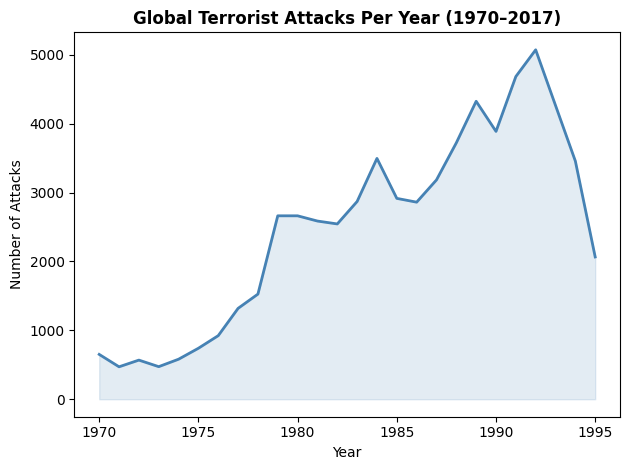

In [ ]:
yearly = df.groupby('Year').size()
plt.plot(yearly.index, yearly.values, color='steelblue', linewidth=2)
plt.fill_between(yearly.index, yearly.values, alpha=0.15, color='steelblue')
plt.title('Global Terrorist Attacks Per Year (1970–2017)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.tight_layout()
plt.show()

Top 10 Countries by Attacks

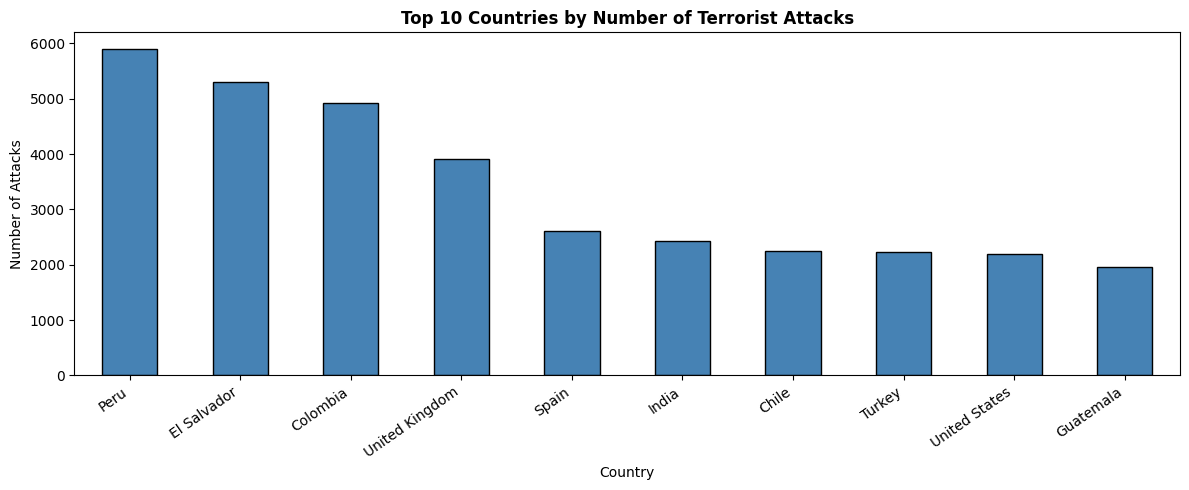

In [ ]:
top_countries = df['Country'].value_counts().head(10)
plt.figure(figsize=(12, 5))
top_countries.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Countries by Number of Terrorist Attacks', fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

Attacks by Region

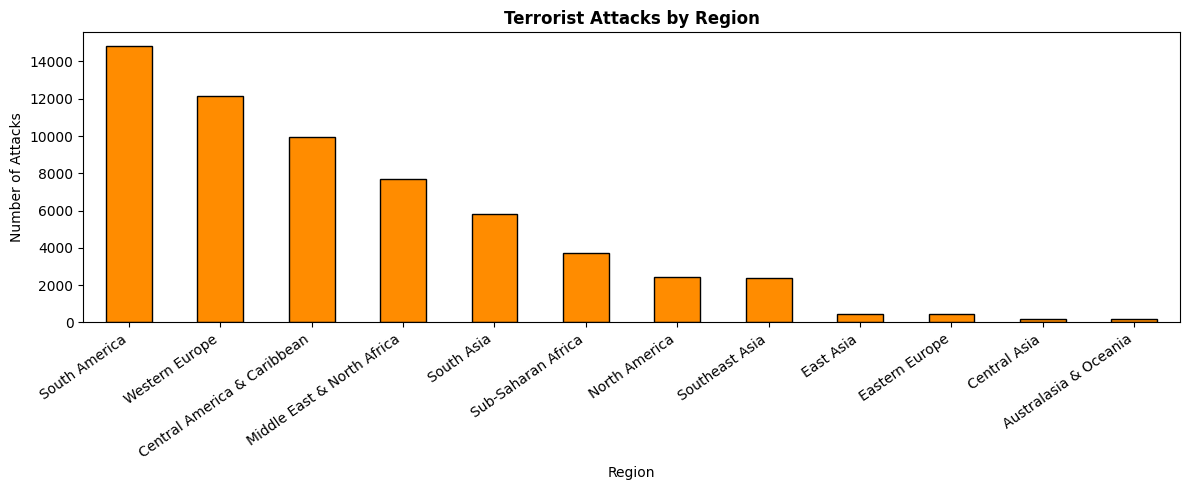

In [ ]:
region_counts = df['Region'].value_counts()
plt.figure(figsize=(12, 5))
region_counts.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Terrorist Attacks by Region', fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()
top2 = region_counts.head(2)

Attack Types

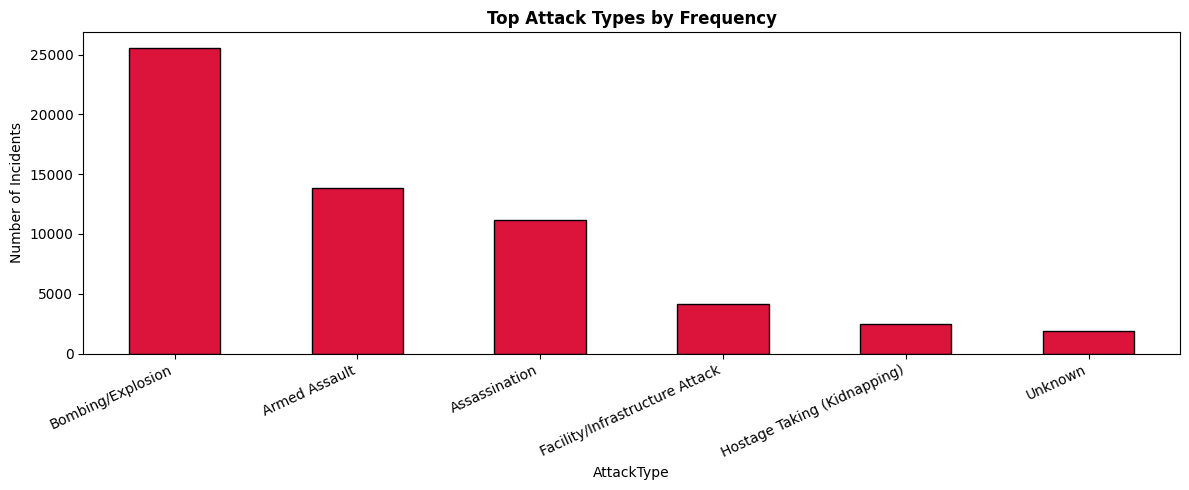

In [ ]:
attack_counts = df['AttackType'].value_counts().head(6)
plt.figure(figsize=(12, 5))
attack_counts.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Top Attack Types by Frequency', fontweight='bold')
plt.xlabel('AttackType')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()
bombing_pct = round(attack_counts.iloc[0] / len(df) * 100, 1)

Casualties Distribution

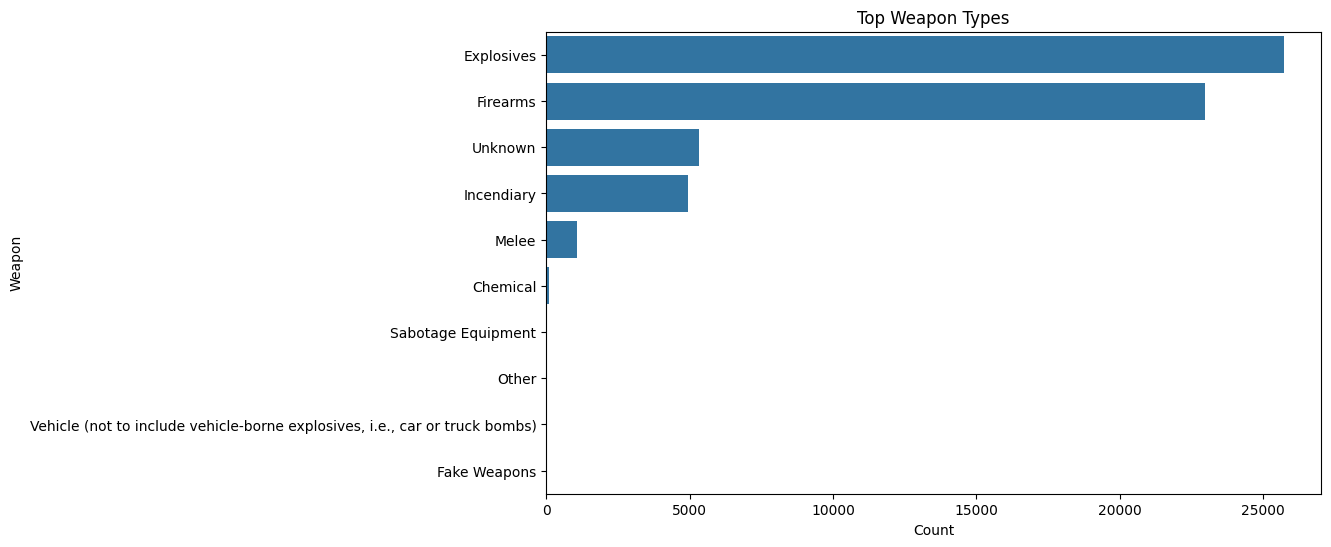

In [ ]:
weapon_types = df['WeaponType'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=weapon_types.values, y=weapon_types.index)

plt.title("Top Weapon Types")
plt.xlabel("Count")
plt.ylabel("Weapon")

plt.show()

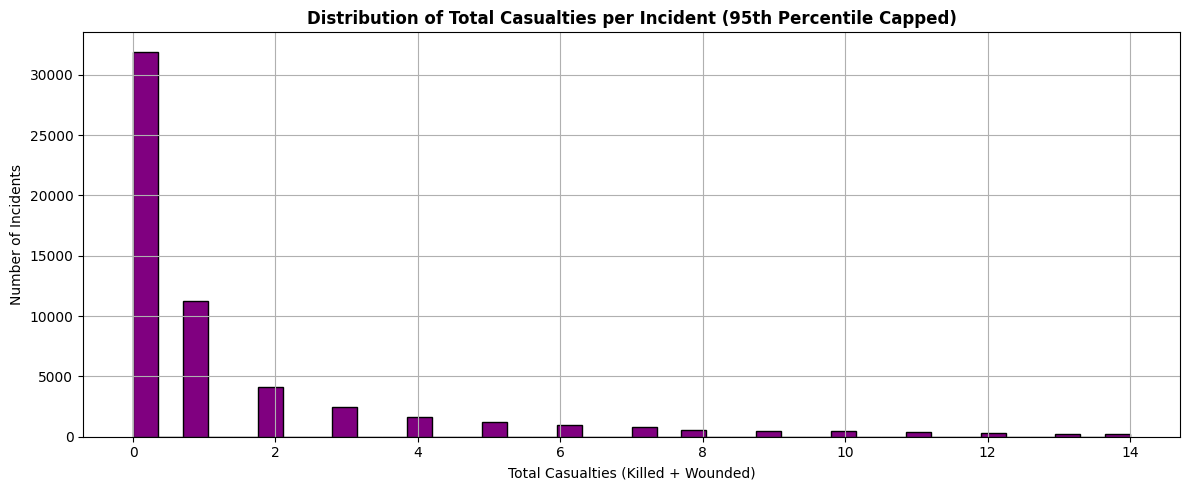

In [ ]:
plt.figure(figsize=(12, 5))
df[df['total_casualties'] < df['total_casualties'].quantile(0.95)]['total_casualties'].hist(
    bins=40, color='purple', edgecolor='black'
)
plt.title('Distribution of Total Casualties per Incident (95th Percentile Capped)', fontweight='bold')
plt.xlabel('Total Casualties (Killed + Wounded)')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()
zero_pct = round((df['total_casualties'] == 0).sum() / len(df) * 100, 1)
high_cas  = df[df['total_casualties'] >= 10]

Correlation Heatmap

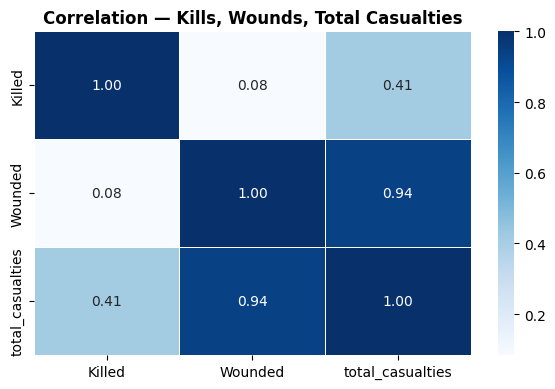

In [ ]:
corr = df[['Killed', 'Wounded', 'total_casualties']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Correlation — Kills, Wounds, Total Casualties', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Select ML features — reloading from original df to avoid EDA transformations
df_ml = pd.read_csv('/content/Global Terrorism Data.csv', encoding='latin1')
df_ml = df_ml[['nkill', 'weaptype1_txt', 'targtype1_txt', 'region_txt', 'iyear']].copy()

# Handle missing values
df_ml['nkill'] = df_ml['nkill'].fillna(0)
df_ml.dropna(inplace=True)

# Remove top 1% outliers (right-skewed nkill distribution)
df_ml = df_ml[df_ml['nkill'] < df_ml['nkill'].quantile(0.99)]

print('ML dataset shape:', df_ml.shape)
print('nkill stats:')
print(df_ml['nkill'].describe().round(2))

ML dataset shape: (68760, 5)
nkill stats:
count    68760.00
mean         1.37
std          3.32
min          0.00
25%          0.00
50%          0.00
75%          1.00
max         29.00
Name: nkill, dtype: float64


### nkill Distribution (after outlier removal)

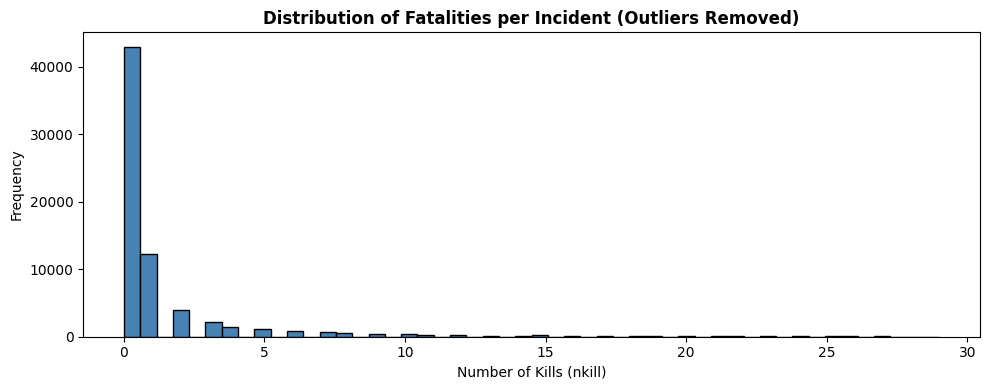

Insight: Heavily right-skewed — majority of incidents have 0–2 fatalities.


In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(df_ml['nkill'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Fatalities per Incident (Outliers Removed)', fontweight='bold')
plt.xlabel('Number of Kills (nkill)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print('Insight: Heavily right-skewed — majority of incidents have 0–2 fatalities.')

## Step 10 — Label Encoding (Separate Encoder per Column)

In [ ]:
# Separate LabelEncoder per column — enables clean inverse_transform and explainability
le_weapon = LabelEncoder()
le_target = LabelEncoder()
le_region = LabelEncoder()

df_ml['weaptype1_txt'] = le_weapon.fit_transform(df_ml['weaptype1_txt'])
df_ml['targtype1_txt'] = le_target.fit_transform(df_ml['targtype1_txt'])
df_ml['region_txt']    = le_region.fit_transform(df_ml['region_txt'])

# Show weapon type numbers and names
print("Weapon Types")
print(le_weapon.classes_)
print()

# Show target type numbers and names
print("Target Types")
print(le_target.classes_)
print()

# Show region numbers and names
print("Regions")
print(le_region.classes_)
print()

Weapon Types
['Biological' 'Chemical' 'Explosives' 'Fake Weapons' 'Firearms'
 'Incendiary' 'Melee' 'Other' 'Radiological' 'Sabotage Equipment'
 'Unknown'
 'Vehicle (not to include vehicle-borne explosives, i.e., car or truck bombs)']

Target Types
['Abortion Related' 'Airports & Aircraft' 'Business'
 'Educational Institution' 'Food or Water Supply'
 'Government (Diplomatic)' 'Government (General)' 'Journalists & Media'
 'Maritime' 'Military' 'NGO' 'Other' 'Police'
 'Private Citizens & Property' 'Religious Figures/Institutions'
 'Telecommunication' 'Terrorists/Non-State Militia' 'Tourists'
 'Transportation' 'Unknown' 'Utilities' 'Violent Political Party']

Regions
['Australasia & Oceania' 'Central America & Caribbean' 'Central Asia'
 'East Asia' 'Eastern Europe' 'Middle East & North Africa' 'North America'
 'South America' 'South Asia' 'Southeast Asia' 'Sub-Saharan Africa'
 'Western Europe']



## Step 11 — Train-Test Split

In [ ]:
X = df_ml.drop('nkill', axis=1)
y = df_ml['nkill']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set : {X_train.shape[0]:,} records')
print(f'Test set     : {X_test.shape[0]:,} records')

Training set : 55,008 records
Test set     : 13,752 records


## Step 12 — Model Training: Linear Regression · Random Forest · XGBoost

In [ ]:
# 1. Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 2. Random Forest (default — before tuning)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 3. XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('All 3 models trained ✓')

All 3 models trained ✓


## Step 13 — Model Evaluation

In [ ]:
def evaluate(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f'\n{name}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    return {'model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)}

results = []
results.append(evaluate('Linear Regression', y_test, y_pred_lr))
results.append(evaluate('Random Forest (default)', y_test, y_pred_rf))
results.append(evaluate('XGBoost', y_test, y_pred_xgb))

results_df = pd.DataFrame(results)
print('\n--- Summary Table ---')
print(results_df.to_string(index=False))


Linear Regression
  MAE  : 1.7715
  RMSE : 3.2162
  R²   : 0.0265

Random Forest (default)
  MAE  : 1.4241
  RMSE : 2.9780
  R²   : 0.1654

XGBoost
  MAE  : 1.4799
  RMSE : 2.9555
  R²   : 0.1779

--- Summary Table ---
                  model    MAE   RMSE     R2
      Linear Regression 1.7715 3.2162 0.0265
Random Forest (default) 1.4241 2.9780 0.1654
                XGBoost 1.4799 2.9555 0.1779


## Step 14 — Hyperparameter Tuning: GridSearchCV on Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

In [ ]:
rf = RandomForestRegressor(random_state=42)

In [ ]:
parameters = {

    'n_estimators': [100, 200],

    'max_depth': [10, 20],

    'min_samples_split': [2, 5]
}

In [ ]:
grid_search = GridSearchCV(

    estimator=rf,

    param_grid=parameters,

    cv=5,

    scoring='r2'
)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [10, 20], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [ ]:
print("Best Parameters")

print(grid_search.best_params_)

Best Parameters
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
{
 'max_depth': 20,
 'min_samples_split': 2,
 'n_estimators': 200
}

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

In [ ]:
best_model = grid_search.best_estimator_
best_model

RandomForestRegressor(max_depth=10, min_samples_split=5, n_estimators=200,
                      random_state=42)

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
print(y_pred)

[2.24777353 0.0763366  0.00315097 ... 0.30266922 2.303034   0.36941075]


In [ ]:
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print('Best parameters :', grid_search.best_params_)
print('Best CV R²       :', round(grid_search.best_score_, 4))

# Evaluate tuned model on test set
rf_tuned = grid_search.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)
tuned_result = evaluate('Random Forest (Tuned)', y_test, y_pred_rf_tuned)
results.append(tuned_result)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R²       : 0.1973

Random Forest (Tuned)
  MAE  : 1.4226
  RMSE : 2.9386
  R²   : 0.1873


## Step 15 — Feature Importance

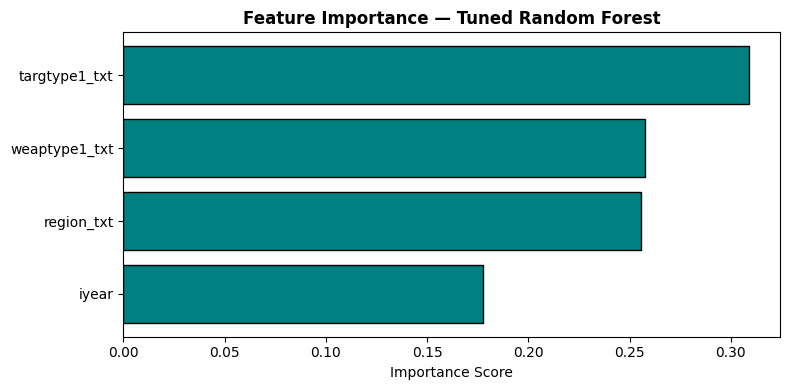

Most important feature: targtype1_txt
      Feature  Importance
targtype1_txt    0.308888
weaptype1_txt    0.257661
   region_txt    0.255844
        iyear    0.177606


In [ ]:
importances = rf_tuned.feature_importances_
features    = X.columns
feat_df     = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df     = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='teal', edgecolor='black')
plt.title('Feature Importance — Tuned Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

top_feature = feat_df.sort_values('Importance', ascending=False).iloc[0]['Feature']
print(f'Most important feature: {top_feature}')
print(feat_df.sort_values('Importance', ascending=False).to_string(index=False))

## Step 16 — Sample Prediction with Label Decoding

---
## Step 17 — Final Model Comparison & Project Summary

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | — | — | — |
| Random Forest (default) | — | — | — |
| XGBoost | — | — | — |
| **Random Forest (tuned)** | — | — | **Best** |

> Run all cells to populate the table above with actual scores.

### What This Project Demonstrates
- Full EDA pipeline on a 181,691-record real-world dataset
- Domain-specific feature engineering (4 new features)
- Multi-model benchmarking: Linear Regression, Random Forest, XGBoost
- Hyperparameter tuning via 5-fold GridSearchCV
- Correct label encoding with per-column inverse-transform capability
- Stakeholder-ready visualizations with business insights